# Vector Error Correction Model (VECM) Parameter Estimation With Two Cointegrating Vectors

In [64]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import vecm, adf, stats, arima
from lib.plots import comparison, stack, twinx, comparison_stack, curve
from lib.data.impl.stats import OLS

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [65]:
def adf_test(xt):
    for i in range(len(xt)):
        result, _ = adf.compute_adf_test(xt[i])
        if result.status_vals[1]:
            print("Not Stationary")
        else:
            print("Stationary")

def plot_vecm_simulation(t, xt, title):
    labels = [r"$x_1$", r"$x_2$", r"$x_3$"]   
    comparison(xt, t, labels =labels, title=title, xlabel=r"$t$", lw=1, title_offset=0.05)

def plot_vecm_dff(dxt, title):
    labels = [r"$\Delta x_1$", r"$\Delta x_2$", r"$\Delta x_3$"]   
    stack(dxt, title=title, ylabels=labels, xlabel=r"$t$", lw=1, title_offset=0.05, figsize=(10, 8))

def pacf_acf_plot(t, dxt, nlags, title):
    acf = [stats.compute_acf(t, samp, nlags=nlags) for samp in dxt] 
    pacf = [arima.compute_pacf(samp, nlags=nlags) for samp in dxt]
    data = [[acf[i][1], pacf[i][1]] for i in range(len(dxt))]
    time = [[acf[i][0], pacf[i][0]] for i in range(len(dxt))]
    comparison_stack(data, time, title=title, xlabel=r"Lag", ylim=(-0.4, 1.0), figsize=(10, 8), 
                     labels=[["ACF", "PACF"]], ylabels=[r"$\Delta x_1$", r"$\Delta x_2$", r"$\Delta x_3$"])

## VECM(1) Two Cointegrating Vectors

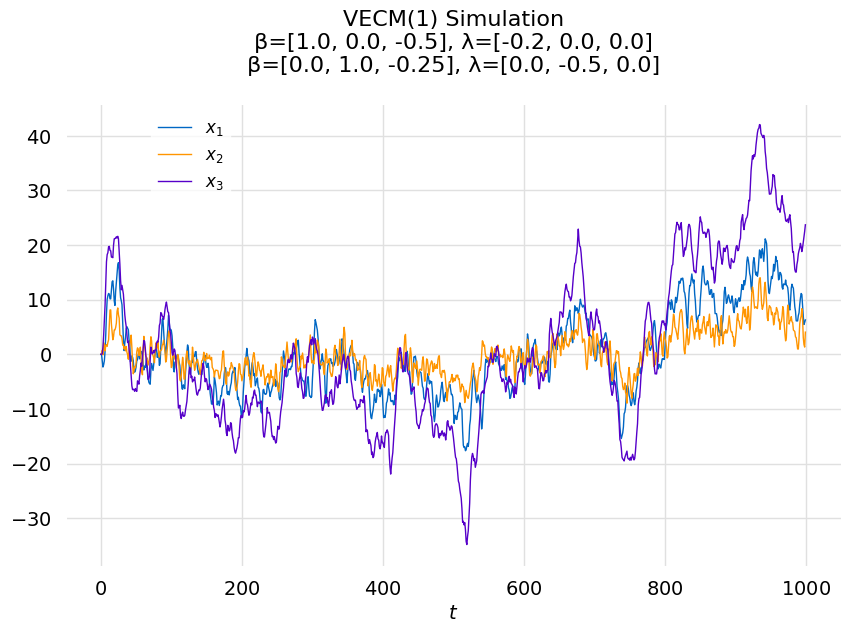

In [66]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.matrix([[0.5, 0.0, 0.0],
                  [0.0, 0.5, 0.0],
                  [0.0, 0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(1) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm1_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [67]:
adf_test(xt)

Stationary
Stationary
Stationary


In [68]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


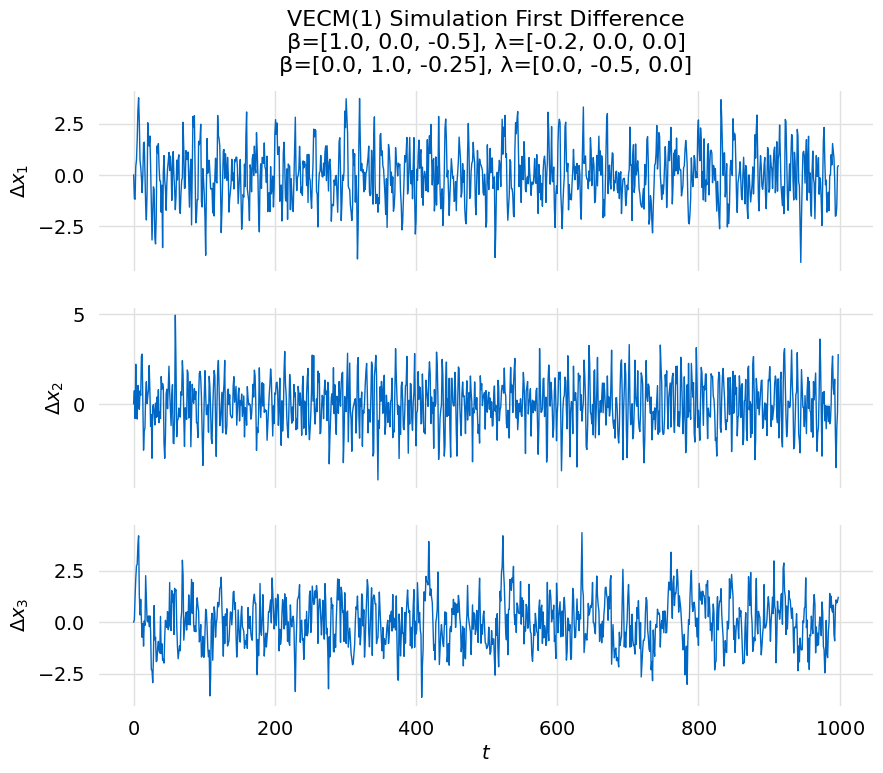

In [69]:
title = f"VECM(1) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [70]:
result, result_model = vecm.compute_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,1.159,1.233,3.188,1.187
1,0.1125*,0.2307*,1.119*,0.1574*
2,0.1136,0.2762,1.120,0.1754
3,0.1156,0.3225,1.123,0.1942
4,0.1231,0.3744,1.131,0.2186


In [71]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "7ce1d97f-b2ff-4716-98ef-2f3ea0dbc40d",
   "_VAROrderTestReport__order": {
      "test_id": "7ce1d97f-b2ff-4716-98ef-2f3ea0dbc40d",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "7ce1d97f-b2ff-4716-98ef-2f3ea0dbc40d",
      "order": {
         "test_id": "7ce1d97f-b2ff-4716-98ef-2f3ea0dbc40d",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "7ce1d97f-b2ff-4716-98ef-2f3ea0dbc40d",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.11246852593350234
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "7ce1d97f-b2ff-4716-98ef-2f3ea0dbc40d",
      "order": {
         "test_id": "7ce1d97f-b2ff-4716-98ef-2f3ea0dbc40d",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "7ce1d97f-b2ff-4716-98ef-2f3ea0dbc40d",
        

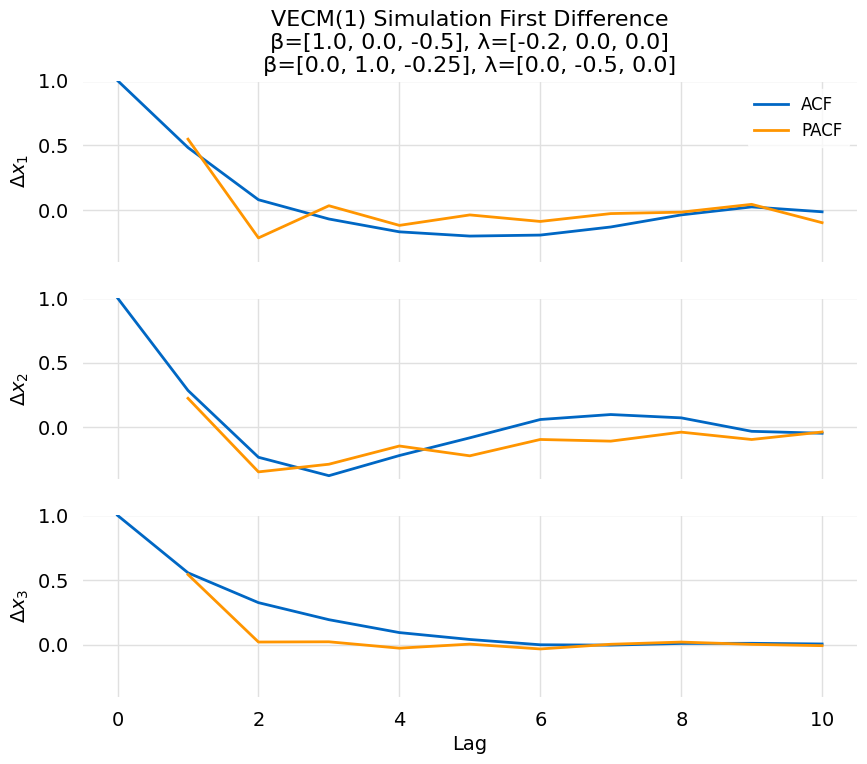

In [72]:
nlags = 10
title = f"VECM(1) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [73]:
result, _ = arima.compute_ar_estimate(dxt[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1547.696
Date:                Sun, 03 Dec 2023   AIC                           3101.393
Time:                        19:04:32   BIC                           3116.113
Sample:                             0   HQIC                          3106.988
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0066      0.070      0.095      0.924      -0.130       0.143
ar.L1          0.4817      0.028     17.273      0.000       0.427       0.536
sigma2         1.2974      0.058     22.558      0.000       1.185       1.410
===================================================================================
Ljung-Box (L1) (Q):                   9.39   Jarque-Bera (JB):                 0.15
Prob(Q):                              0.00   Prob(JB):                         0.93
Heteroskedasticity (H):               0.85   Skew:                             0.02
Prob(H) (two-sided):                  0.13   Kurtosis:                         3.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [74]:
result, _ = arima.compute_ar_estimate(dxt[1], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1691.467
Date:                Sun, 03 Dec 2023   AIC                           3388.935
Time:                        19:04:32   BIC                           3403.655
Sample:                             0   HQIC                          3394.530
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0052      0.058      0.089      0.929      -0.109       0.120
ar.L1          0.2862      0.032      8.807      0.000       0.222       0.350
sigma2         1.7305      0.079     21.965      0.000       1.576       1.885
===================================================================================
Ljung-Box (L1) (Q):                   9.60   Jarque-Bera (JB):                 1.46
Prob(Q):                              0.00   Prob(JB):                         0.48
Heteroskedasticity (H):               1.20   Skew:                            -0.09
Prob(H) (two-sided):                  0.10   Kurtosis:                         2.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [75]:
result, _ = arima.compute_ar_estimate(dxt[2], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1404.918
Date:                Sun, 03 Dec 2023   AIC                           2815.836
Time:                        19:04:32   BIC                           2830.556
Sample:                             0   HQIC                          2821.431
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0252      0.071      0.357      0.721      -0.113       0.163
ar.L1          0.5562      0.026     21.527      0.000       0.506       0.607
sigma2         0.9747      0.043     22.807      0.000       0.891       1.058
===================================================================================
Ljung-Box (L1) (Q):                   0.16   Jarque-Bera (JB):                 0.31
Prob(Q):                              0.69   Prob(JB):                         0.86
Heteroskedasticity (H):               0.96   Skew:                            -0.01
Prob(H) (two-sided):                  0.74   Kurtosis:                         3.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [76]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=1)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=301.6589, p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.2740  , p=0.1319  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=2.2809  , p=0.1310  , df=1
likelihood ratio test: chi2=2.2783  , p=0.1312  , df=1
parameter F test:         F=2.2740  , p=0.1319  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=39.2671 , p=0.0000  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=39.3855 , p=0.0000  , df=1
likelihood ratio test: chi2=38.6282 , p=0.0000  , df=1
parameter F test:         F=39.2671 , p=0.0000  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.9835  , p=0.0462  

In [77]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.1319,0.05,False,1,2
3,0.0000,0.05,True,1,3
4,0.0462,0.05,True,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.0077,0.05,True,3,1
8,0.5934,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [78]:
print(result_model.to_json(pretty=True))

{
   "test_id": "13f81be8-f9bf-4c52-99b1-ea5af1ca367a",
   "rank": 3,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "13f81be8-f9bf-4c52-99b1-ea5af1ca367a",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "13f81be8-f9bf-4c52-99b1-ea5af1ca367a",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.1319,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "13f81be8-f9bf-4c52-99b1-ea5af1ca367a",
         "_GrangerCausalityTestResult__de

### Johansen Test for Cointegration

In [79]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 1)

In [80]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          633.224 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          191.041 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            4.091 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [81]:
print(result_model.to_json(pretty=True))

{
   "test_id": "f780243e-cdcd-4b49-b3c2-f6a5e0313e20",
   "trace_test": [
      {
         "test_id": "f780243e-cdcd-4b49-b3c2-f6a5e0313e20",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 633.2237345480821,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            true,
            true
         ]
      },
      {
         "test_id": "f780243e-cdcd-4b49-b3c2-f6a5e0313e20",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 191.04087475524932,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.matrix([[0.5, 0.0, 0.0],
                  [0.0, 0.5, 0.0],
                  [0.0, 0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```

In [82]:
result, result_model = vecm.compute_estimate(xt, maxlags=1, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0165,0.032,-0.511,0.609,-0.080,0.047
L1.y1,0.5209,0.026,20.408,0.000,0.471,0.571
L1.y2,0.0159,0.026,0.612,0.540,-0.035,0.067
L1.y3,0.0486,0.030,1.626,0.104,-0.010,0.107
,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0041,0.033,-0.126,0.900,-0.069,0.060
L1.y1,0.0264,0.026,1.015,0.310,-0.025,0.077
L1.y2,0.5213,0.026,19.679,0.000,0.469,0.573
L1.y3,0.0330,0.030,1.083,0.279,-0.027,0.093
,coef,std err,z,P>|z|,[0.025,0.975]


In [83]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": -0.016494221878332146,
         "err": 0.03227676913126936,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "1b16b449-e9a6-4ce8-837e-45e9b82dc2ef",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.0041300720474198,
         "err": 0.03288295747256762,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "1b16b449-e9a6-4ce8-837e-45e9b82dc2ef",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.012319586084411903,
         "err": 0.031159743844609646,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "1b16b449-e9a6-4ce8-837e-45e9b82dc2ef",
         "param_ty

### Verify Error Correction term Residual Stationarity

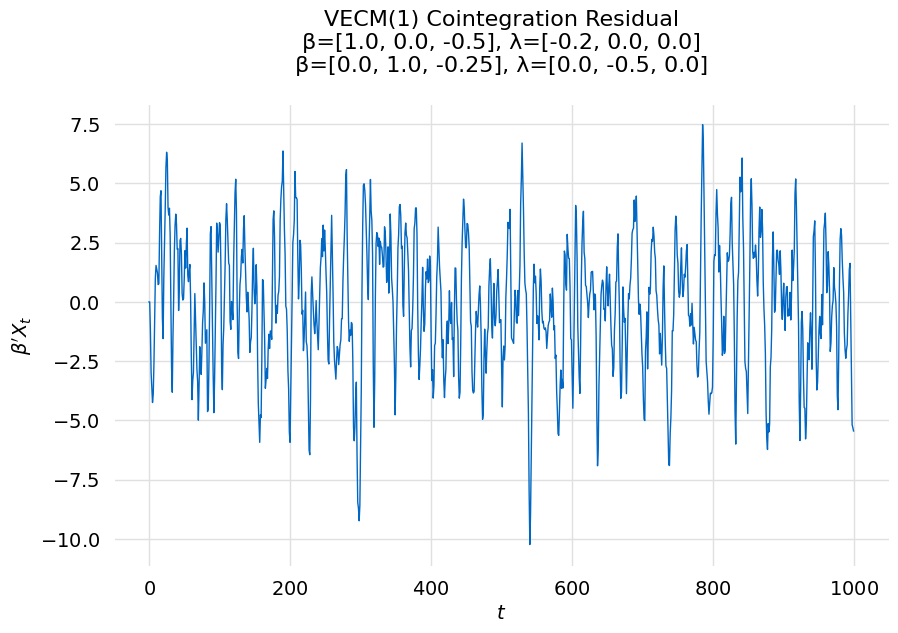

In [84]:
beta_est = result.beta
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [85]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -12.6437      │
├────────────────┼───────────────┤
│ pvalue         │   4.56893e-23 │
├────────────────┼───────────────┤
│ Lags           │   3           │
├────────────────┼───────────────┤
│ Number Obs     │ 996           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## VECM(2) Two Cointegrating Vectors

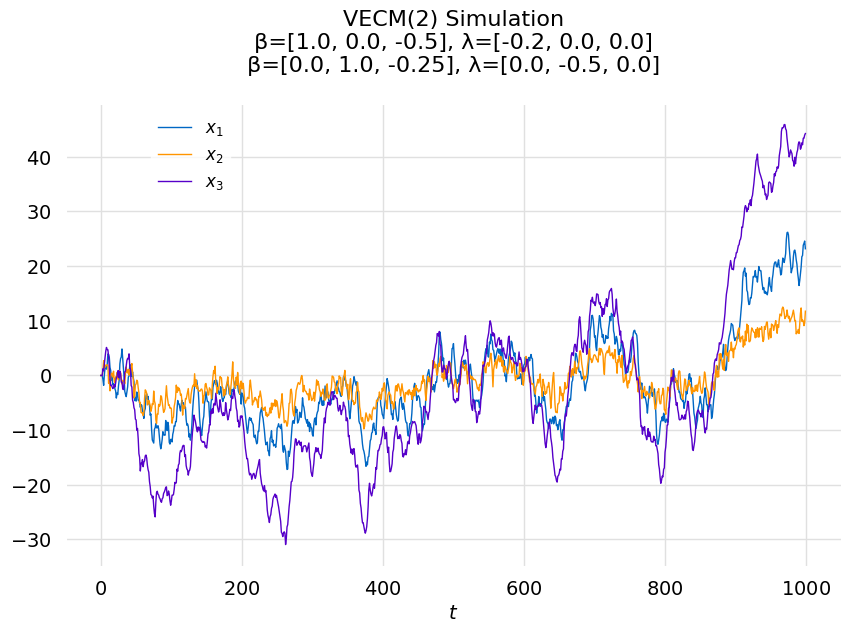

In [86]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(2) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [87]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [88]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


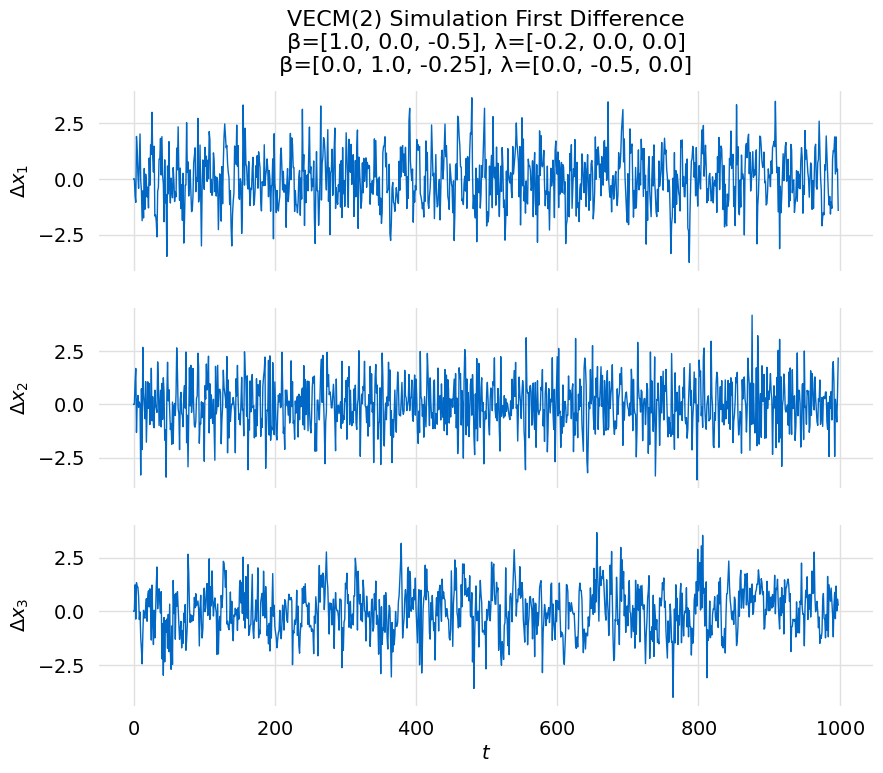

In [89]:
title = f"VECM(2) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [90]:
result, result_model = vecm.compute_order(xt, maxlags=6)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.5143,0.5884,1.673,0.5425
1,0.2667,0.3851,1.306,0.3117
2,0.09680*,0.2597*,1.102*,0.1587*
3,0.1088,0.3161,1.115,0.1877
4,0.1194,0.3711,1.127,0.2151
5,0.1305,0.4266,1.139,0.2431
6,0.1438,0.4843,1.155,0.2733


In [91]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "37aa2bad-f50f-4800-bdc9-dc3ca88c721a",
   "_VAROrderTestReport__order": {
      "test_id": "37aa2bad-f50f-4800-bdc9-dc3ca88c721a",
      "label": "$\\tau_{min}$",
      "value": 2
   },
   "_VAROrderTestReport__aic": {
      "test_id": "37aa2bad-f50f-4800-bdc9-dc3ca88c721a",
      "order": {
         "test_id": "37aa2bad-f50f-4800-bdc9-dc3ca88c721a",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "37aa2bad-f50f-4800-bdc9-dc3ca88c721a",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.09679771401815593
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "37aa2bad-f50f-4800-bdc9-dc3ca88c721a",
      "order": {
         "test_id": "37aa2bad-f50f-4800-bdc9-dc3ca88c721a",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "37aa2bad-f50f-4800-bdc9-dc3ca88c721a",
        

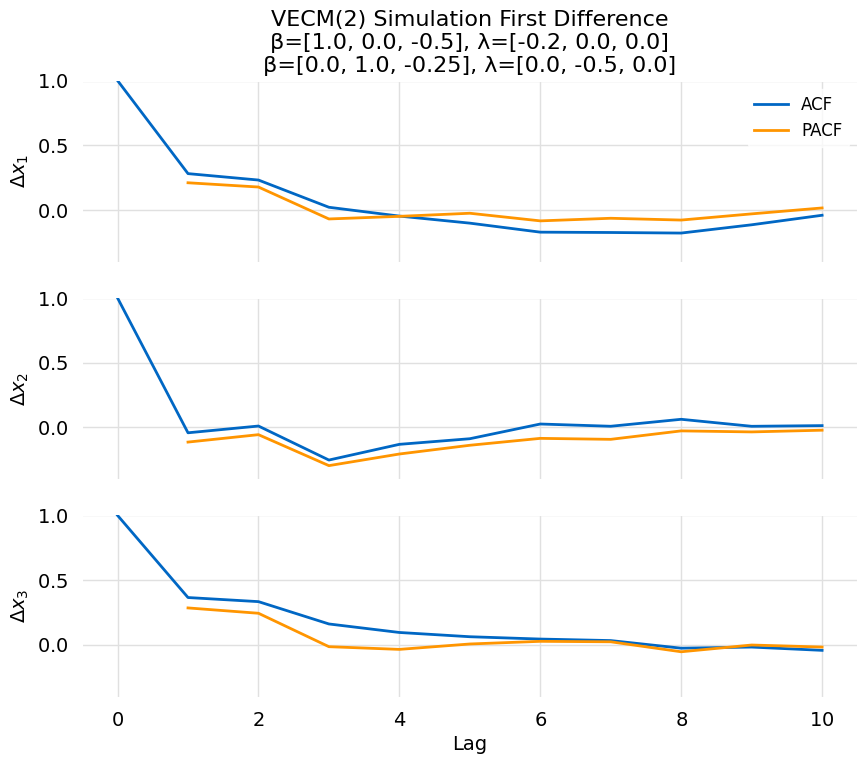

In [92]:
nlags = 10
title = f"VECM(2) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [93]:
result, _ = arima.compute_ar_estimate(dxt[0], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1547.609
Date:                Sun, 03 Dec 2023   AIC                           3103.218
Time:                        19:04:35   BIC                           3122.845
Sample:                             0   HQIC                          3110.678
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0223      0.060      0.370      0.711      -0.096       0.141
ar.L1          0.2344      0.033      7.201      0.000       0.171       0.298
ar.L2          0.1651      0.032      5.215      0.000       0.103       0.227
sigma2         1.2973      0.057     22.702      0.000       1.185       1.409
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                 0.90
Prob(Q):                              0.64   Prob(JB):                         0.64
Heteroskedasticity (H):               0.88   Skew:                             0.06
Prob(H) (two-sided):                  0.24   Kurtosis:                         3.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [94]:
result, _ = arima.compute_ar_estimate(dxt[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1587.815
Date:                Sun, 03 Dec 2023   AIC                           3183.630
Time:                        19:04:35   BIC                           3203.257
Sample:                             0   HQIC                          3191.090
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0117      0.036      0.322      0.748      -0.060       0.083
ar.L1         -0.0416      0.031     -1.334      0.182      -0.103       0.019
ar.L2          0.0087      0.031      0.284      0.777      -0.051       0.069
sigma2         1.4062      0.063     22.348      0.000       1.283       1.530
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.17
Prob(Q):                              0.95   Prob(JB):                         0.92
Heteroskedasticity (H):               1.04   Skew:                            -0.03
Prob(H) (two-sided):                  0.69   Kurtosis:                         3.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [95]:
result, _ = arima.compute_ar_estimate(dxt[2], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1428.300
Date:                Sun, 03 Dec 2023   AIC                           2864.600
Time:                        19:04:35   BIC                           2884.227
Sample:                             0   HQIC                          2872.060
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0447      0.066      0.679      0.497      -0.084       0.174
ar.L1          0.2805      0.033      8.590      0.000       0.217       0.345
ar.L2          0.2306      0.028      8.135      0.000       0.175       0.286
sigma2         1.0216      0.043     24.030      0.000       0.938       1.105
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 8.37
Prob(Q):                              0.87   Prob(JB):                         0.02
Heteroskedasticity (H):               1.04   Skew:                            -0.15
Prob(H) (two-sided):                  0.70   Kurtosis:                         3.33
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [96]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=85.4339 , p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=-0.0000 , p=1.0000  , df_denom=994, df_num=2
ssr based chi2 test:   chi2=-0.0000 , p=1.0000  , df=2
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=2
parameter F test:         F=57.7939 , p=0.0000  , df_denom=994, df_num=2

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=13.3370 , p=0.0003  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=13.3772 , p=0.0003  , df=1
likelihood ratio test: chi2=13.2883 , p=0.0003  , df=1
parameter F test:         F=13.3370 , p=0.0003  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=9.8206  , p=0.0001  

In [97]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.0001,0.05,True,1,2
3,0.0000,0.05,True,1,3
4,0.1473,0.05,False,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.4420,0.05,False,3,1
8,0.0296,0.05,True,3,2
9,1.0000,0.05,False,3,3


In [98]:
print(result_model.to_json(pretty=True))

{
   "test_id": "a43e55e6-c118-4a8b-b965-5ee17c0ac288",
   "rank": 3,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "a43e55e6-c118-4a8b-b965-5ee17c0ac288",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "a43e55e6-c118-4a8b-b965-5ee17c0ac288",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.0001,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": true
      },
      {
         "_GrangerCausalityTestResult__est_id": "a43e55e6-c118-4a8b-b965-5ee17c0ac288",
         "_GrangerCausalityTestResult__dep

### Johansen Test for Cointegration

In [99]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 2)

In [100]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          473.447 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          172.990 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            0.873 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [101]:
print(result_model.to_json(pretty=True))

{
   "test_id": "8d99824e-1363-49af-a392-9623ddbd57fb",
   "trace_test": [
      {
         "test_id": "8d99824e-1363-49af-a392-9623ddbd57fb",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 473.4471283422081,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            true,
            true
         ]
      },
      {
         "test_id": "8d99824e-1363-49af-a392-9623ddbd57fb",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 172.99049081595157,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```



In [102]:
result, result_model = vecm.compute_estimate(xt, maxlags=2, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0277,0.032,0.859,0.390,-0.035,0.091
L1.y1,0.2437,0.029,8.481,0.000,0.187,0.300
L1.y2,0.0058,0.032,0.180,0.857,-0.057,0.068
L1.y3,0.0003,0.033,0.009,0.993,-0.065,0.065
L2.y1,0.2468,0.029,8.564,0.000,0.190,0.303
L2.y2,0.0087,0.031,0.283,0.778,-0.051,0.069
L2.y3,0.0202,0.034,0.596,0.551,-0.046,0.086
,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0406,0.032,-1.273,0.203,-0.103,0.022
L1.y1,0.0272,0.028,0.955,0.340,-0.029,0.083


In [103]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": 0.027659807543766027,
         "err": 0.0321869179754132,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "6f5a743b-6409-417f-abc6-17498b5fb946",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.040591714606490574,
         "err": 0.031876024564865976,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "6f5a743b-6409-417f-abc6-17498b5fb946",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.030000458169440636,
         "err": 0.03202091231031778,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "6f5a743b-6409-417f-abc6-17498b5fb946",
         "param_ty

### Verify Error Correction term Residual Stationarity

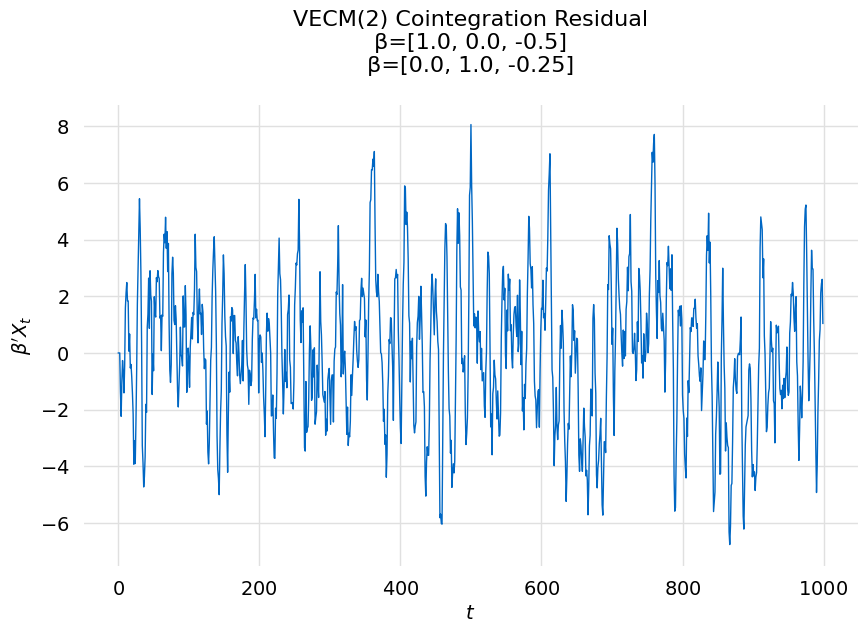

In [104]:
beta_est = result.beta
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(2) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [105]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -12.9376      │
├────────────────┼───────────────┤
│ pvalue         │   1.38683e-23 │
├────────────────┼───────────────┤
│ Lags           │   2           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## VECM(3) Two Cointegrating Vectors

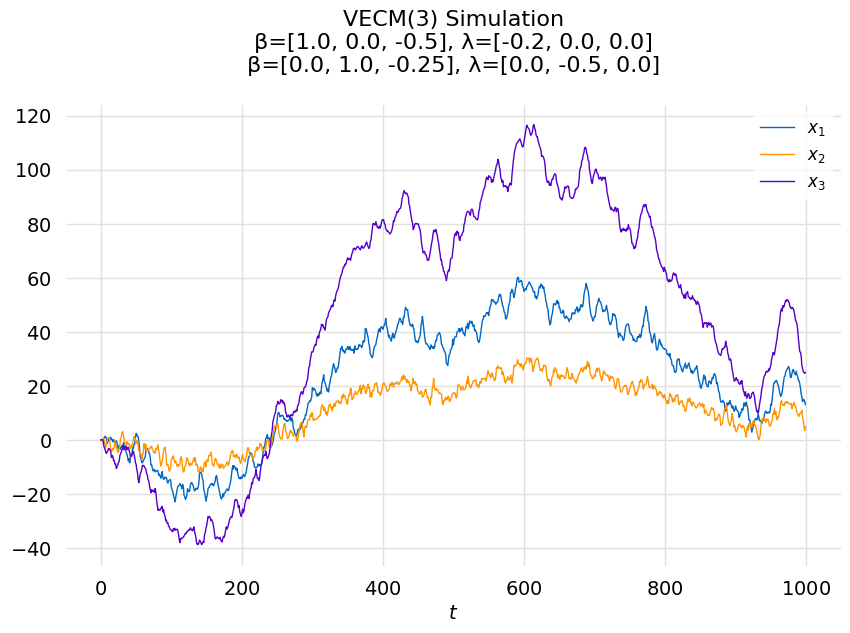

In [106]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.1, 0.0, 0.0],
                  [0.0, 0.1, 0.0],
                  [0.0, 0.0, 0.1]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(3) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [107]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [108]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


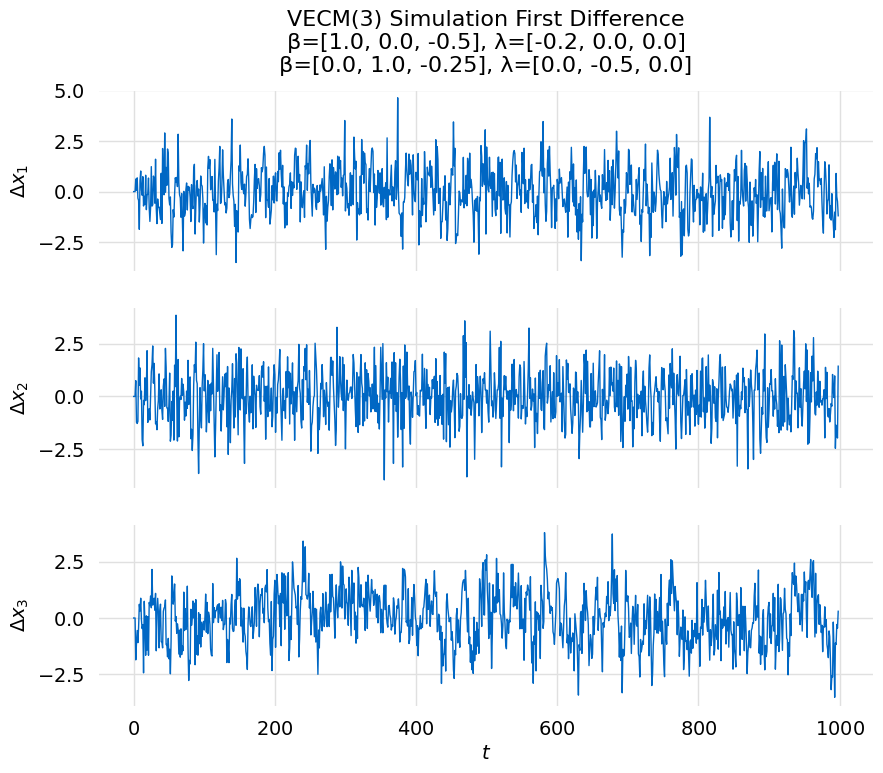

In [109]:
title = f"VECM(3) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [110]:
result, result_model = vecm.compute_order(xt, maxlags=6)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.7115,0.7855,2.037,0.7396
1,0.3605,0.4789,1.434,0.4055
2,0.1141,0.2770*,1.121,0.1760
3,0.09627*,0.3036,1.101*,0.1751*
4,0.1003,0.3520,1.106,0.1960
5,0.1138,0.4099,1.121,0.2264
6,0.1280,0.4685,1.137,0.2575


In [111]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "24d1533f-1394-4dc7-a752-ab5198508e8f",
   "_VAROrderTestReport__order": {
      "test_id": "24d1533f-1394-4dc7-a752-ab5198508e8f",
      "label": "$\\tau_{min}$",
      "value": 3
   },
   "_VAROrderTestReport__aic": {
      "test_id": "24d1533f-1394-4dc7-a752-ab5198508e8f",
      "order": {
         "test_id": "24d1533f-1394-4dc7-a752-ab5198508e8f",
         "label": "$\\tau_{AIC}$",
         "value": 3
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "24d1533f-1394-4dc7-a752-ab5198508e8f",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.09627009669579507
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "24d1533f-1394-4dc7-a752-ab5198508e8f",
      "order": {
         "test_id": "24d1533f-1394-4dc7-a752-ab5198508e8f",
         "label": "$\\tau_{BIC}$",
         "value": 3
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "24d1533f-1394-4dc7-a752-ab5198508e8f",
        

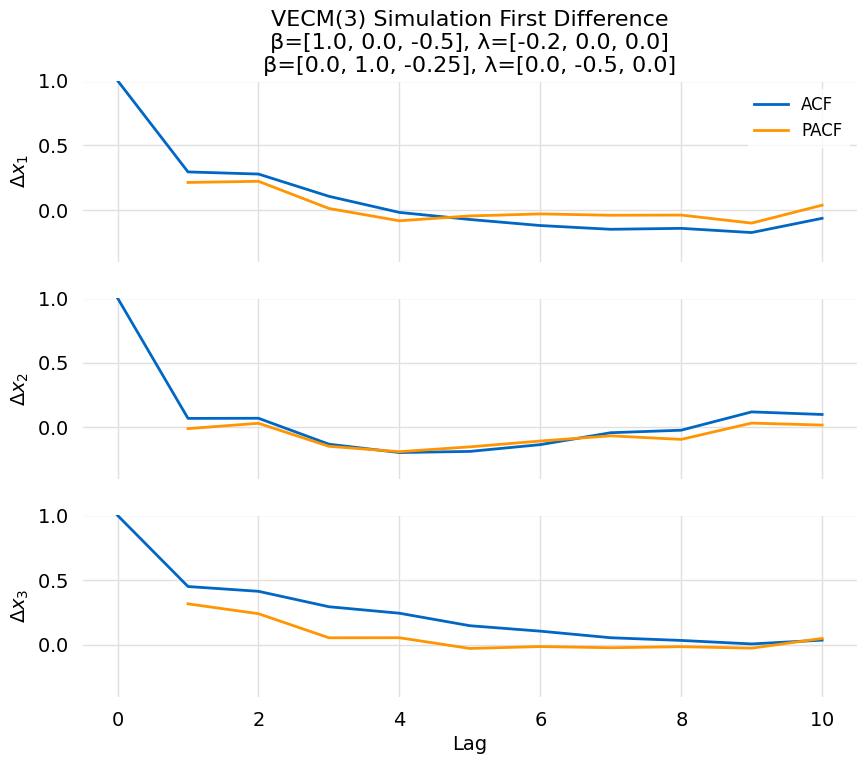

In [112]:
nlags = 10
title = f"VECM(3) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [113]:
result, _ = arima.compute_ar_estimate(dxt[0], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1535.744
Date:                Sun, 03 Dec 2023   AIC                           3081.487
Time:                        19:04:38   BIC                           3106.021
Sample:                             0   HQIC                          3090.812
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0120      0.063      0.192      0.848      -0.111       0.135
ar.L1          0.2375      0.033      7.284      0.000       0.174       0.301
ar.L2          0.2145      0.032      6.687      0.000       0.152       0.277
ar.L3         -0.0234      0.032     -0.738      0.461      -0.086       0.039
sigma2         1.2668      0.055     23.138      0.000       1.159       1.374
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 1.25
Prob(Q):                              0.94   Prob(JB):                         0.54
Heteroskedasticity (H):               1.14   Skew:                             0.04
Prob(H) (two-sided):                  0.24   Kurtosis:                         3.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [114]:
result, _ = arima.compute_ar_estimate(dxt[1], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1582.243
Date:                Sun, 03 Dec 2023   AIC                           3174.486
Time:                        19:04:38   BIC                           3199.020
Sample:                             0   HQIC                          3183.811
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0052      0.038      0.137      0.891      -0.069       0.080
ar.L1          0.0743      0.032      2.345      0.019       0.012       0.136
ar.L2          0.0750      0.030      2.486      0.013       0.016       0.134
ar.L3         -0.1409      0.030     -4.738      0.000      -0.199      -0.083
sigma2         1.3905      0.062     22.603      0.000       1.270       1.511
===================================================================================
Ljung-Box (L1) (Q):                   0.69   Jarque-Bera (JB):                 0.57
Prob(Q):                              0.41   Prob(JB):                         0.75
Heteroskedasticity (H):               0.92   Skew:                            -0.05
Prob(H) (two-sided):                  0.46   Kurtosis:                         3.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [115]:
result, _ = arima.compute_ar_estimate(dxt[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1429.484
Date:                Sun, 03 Dec 2023   AIC                           2868.969
Time:                        19:04:38   BIC                           2893.503
Sample:                             0   HQIC                          2878.294
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0249      0.084      0.298      0.766      -0.139       0.189
ar.L1          0.3173      0.031     10.162      0.000       0.256       0.379
ar.L2          0.2466      0.034      7.298      0.000       0.180       0.313
ar.L3          0.0514      0.032      1.591      0.112      -0.012       0.115
sigma2         1.0239      0.045     22.517      0.000       0.935       1.113
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.29
Prob(Q):                              0.96   Prob(JB):                         0.87
Heteroskedasticity (H):               1.07   Skew:                             0.04
Prob(H) (two-sided):                  0.52   Kurtosis:                         3.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [116]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=94.2765 , p=0.0000  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=-0.0000 , p=1.0000  , df_denom=994, df_num=2
ssr based chi2 test:   chi2=-0.0000 , p=1.0000  , df=2
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=2
parameter F test:         F=72.0399 , p=0.0000  , df_denom=994, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=992, df_num=3
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=3
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=3
parameter F test:         F=48.1390 , p=0.0000  , df_denom=992, df_num=3

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.5130  , p=0.0612  

In [117]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.0048,0.05,True,1,2
3,0.0000,0.05,True,1,3
4,0.4112,0.05,False,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.0620,0.05,False,3,1
8,0.0724,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [118]:
print(result_model.to_json(pretty=True))

{
   "test_id": "f413066d-88ff-4571-8a0e-a1ee7a88f24e",
   "rank": 2,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "f413066d-88ff-4571-8a0e-a1ee7a88f24e",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "f413066d-88ff-4571-8a0e-a1ee7a88f24e",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.0048,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": true
      },
      {
         "_GrangerCausalityTestResult__est_id": "f413066d-88ff-4571-8a0e-a1ee7a88f24e",
         "_GrangerCausalityTestResult__dep

### Johansen Test for Cointegration

In [119]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 3)

In [120]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          433.257 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          158.866 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            1.284 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [121]:
print(result_model.to_json(pretty=True))

{
   "test_id": "91143556-14e0-4c8b-9b28-5985116069fe",
   "trace_test": [
      {
         "test_id": "91143556-14e0-4c8b-9b28-5985116069fe",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 433.2571451000111,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            true,
            true
         ]
      },
      {
         "test_id": "91143556-14e0-4c8b-9b28-5985116069fe",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 158.86591152190218,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.1, 0.0, 0.0],
                  [0.0, 0.1, 0.0],
                  [0.0, 0.0, 0.1]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```



In [122]:
result, result_model = vecm.compute_estimate(xt, maxlags=3, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0092,0.032,-0.287,0.774,-0.072,0.054
L1.y1,0.2238,0.029,7.650,0.000,0.166,0.281
L1.y2,0.0037,0.031,0.119,0.905,-0.058,0.065
L1.y3,0.0131,0.033,0.394,0.694,-0.052,0.079
L2.y1,0.2732,0.030,9.257,0.000,0.215,0.331
L2.y2,0.0014,0.031,0.044,0.965,-0.060,0.063
L2.y3,0.0203,0.034,0.596,0.551,-0.047,0.087
L3.y1,0.0962,0.030,3.191,0.001,0.037,0.155
L3.y2,0.0559,0.031,1.778,0.075,-0.006,0.118
L3.y3,-0.0209,0.035,-0.603,0.546,-0.089,0.047


In [123]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": -0.009200295484473564,
         "err": 0.03206683227878208,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "c5993794-9add-4195-84cd-8db40442ecc7",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.0027483168688409347,
         "err": 0.03139454719660655,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "c5993794-9add-4195-84cd-8db40442ecc7",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.010781622597265823,
         "err": 0.031853279523441545,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "c5993794-9add-4195-84cd-8db40442ecc7",
         "param

### Verify Error Correction term Residual Stationarity

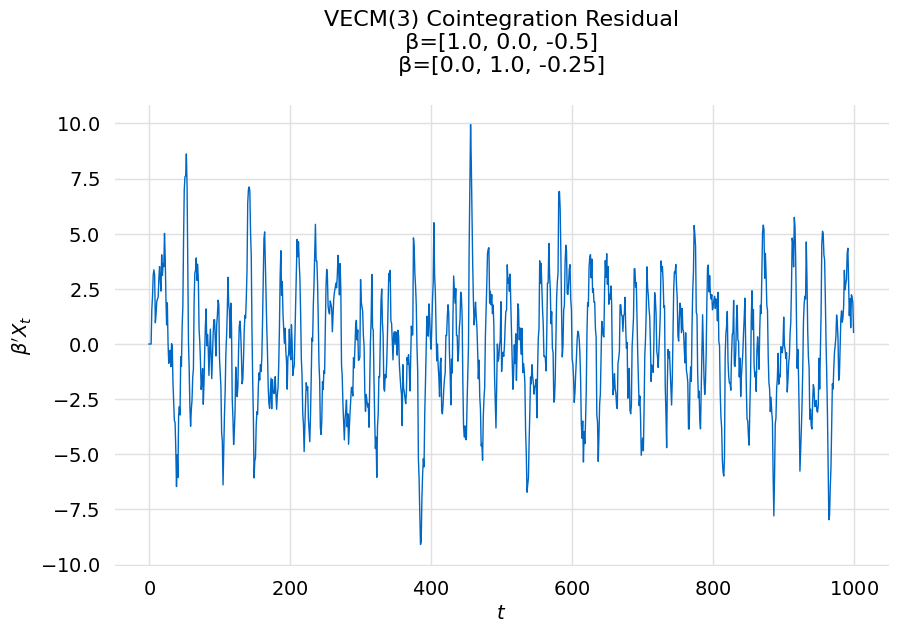

In [124]:
beta_est = result.beta
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(3) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [125]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -13.1579      │
├────────────────┼───────────────┤
│ pvalue         │   5.83438e-24 │
├────────────────┼───────────────┤
│ Lags           │   3           │
├────────────────┼───────────────┤
│ Number Obs     │ 996           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛
